# ML pipeline tittanic (lew1sh)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [2]:
df_train = pd.read_csv('../data/train.csv',sep=',',index_col='PassengerId')
df_test = pd.read_csv('../data/test.csv',sep=',',index_col='PassengerId')

# EDA


In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [4]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    object 
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     object 
 9   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 35.9+ KB


In [5]:
df_train.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
num_df = df_train.select_dtypes(include='number')

In [7]:
num_df.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [8]:
for  feature in df_train.columns:
    if not df_train[df_train[feature].isnull()].empty:
        print(f'-----------------{feature}---------')
        print(f'count empty values = {df_train[feature].isnull().sum()}')
        print(f' % empty values = {df_train[feature].isnull().mean()}')

-----------------Age---------
count empty values = 177
 % empty values = 0.19865319865319866
-----------------Cabin---------
count empty values = 687
 % empty values = 0.7710437710437711
-----------------Embarked---------
count empty values = 2
 % empty values = 0.002244668911335578


### Вывод

Пропуски обнаружены в трех признаках:

- `Cabin`:  около 77.1% данных. Признак нельзя напрямую использовать без обработки, поэтому дальше создается бинарный признак `HasCabin`.
- `Age`:  около 19.9% данных. Пропуски стоит заполнить средним или медианным значением.
- `Embarked`:  около 0.2% данных. Так как пропусков очень мало, их можно заполнить модой.(так как категориальное зн)


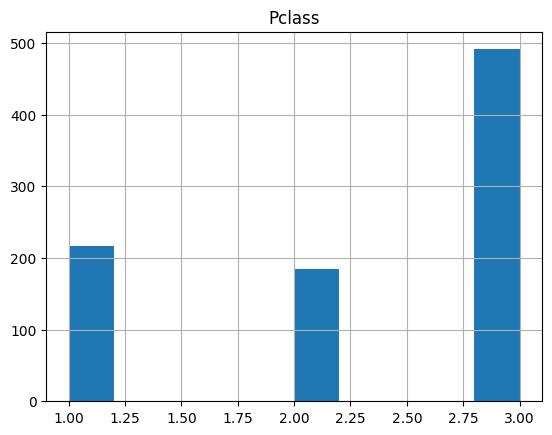

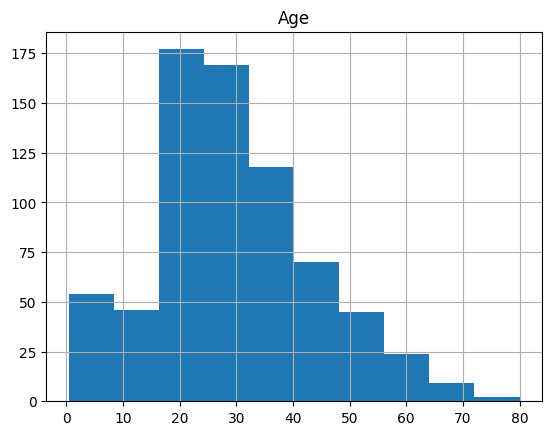

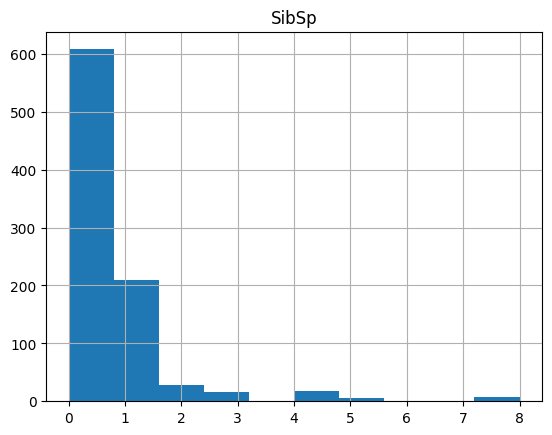

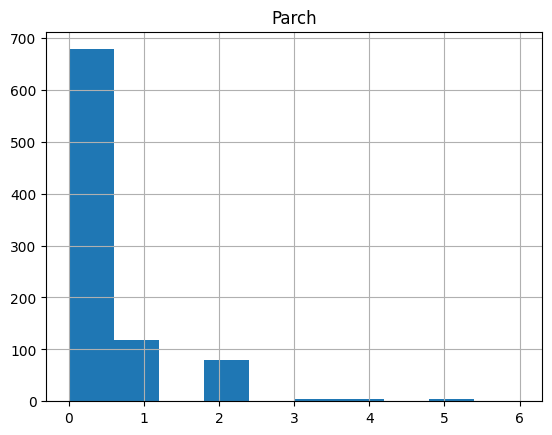

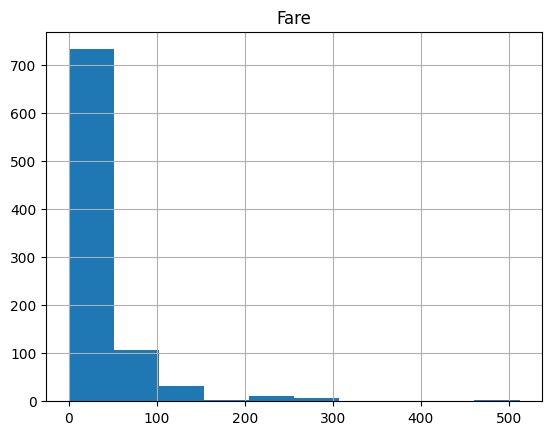

In [9]:

for  feature in num_df.columns[1:]:
    plt.title(feature)
    df_train[feature].hist()
    plt.show()
    

### Вывод

Числовые признаки имеют разную природу: `Pclass`, `SibSp` и `Parch` являются дискретными, а `Age` и `Fare` — непрерывными. `SibSp`, `Parch` и особенно `Fare` имеют правосторонний перекос: большинство значений маленькие, а большие значения встречаются редко. Для `Fare` это указывает на необходимость логарифмирования, `Age` содержит широкий диапазон возрастов и заметную долю пропусков, поэтому требует заполнения перед обучением модели.

In [10]:
num_df.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

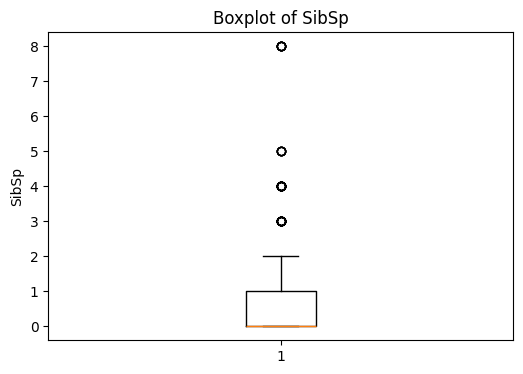

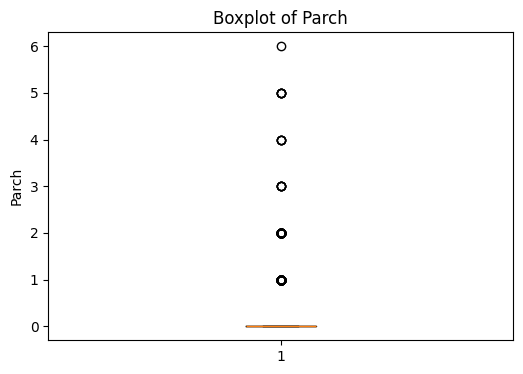

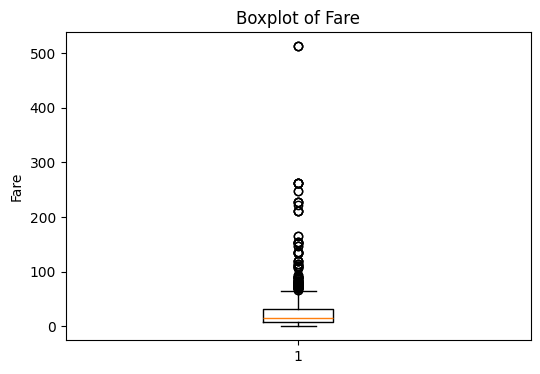

In [12]:
for feature in ["SibSp", "Parch", "Fare"]:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df_train[feature].dropna(), vert=True)
    plt.title(f"Boxplot of {feature}")
    plt.ylabel(feature)
    plt.show()

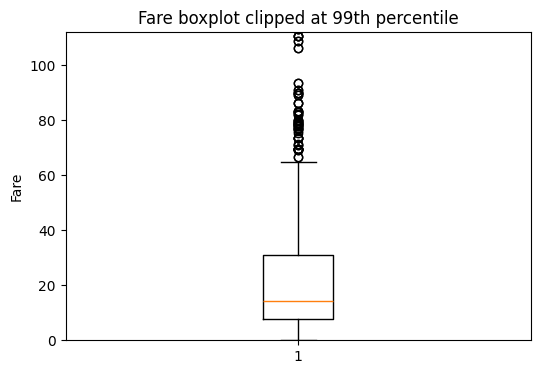

In [21]:
plt.figure(figsize=(6, 4))
plt.boxplot(df_train["Fare"].dropna())
plt.ylim(0, df_train["Fare"].quantile(0.95))
plt.title("Fare boxplot clipped at 99th percentile")
plt.ylabel("Fare")
plt.show()

# ### Вывод

У `SibSp`, `Parch` и `Fare` видны редкие большие значения. Для `SibSp` и `Parch` эти значения скорее отражают большие семьи, поэтому их лучше не удалять. Для `Fare` выбросы выражены сильнее: дорогие билеты могут заметно влиять на линейные модели и нейросеть, поэтому в основном pipeline применяется логарифмирование `log1p(Fare)`.

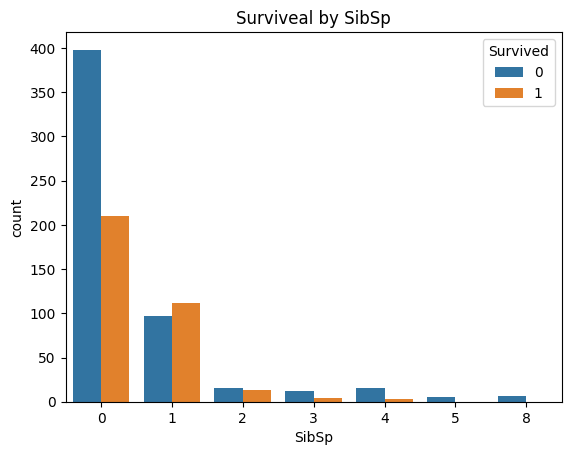

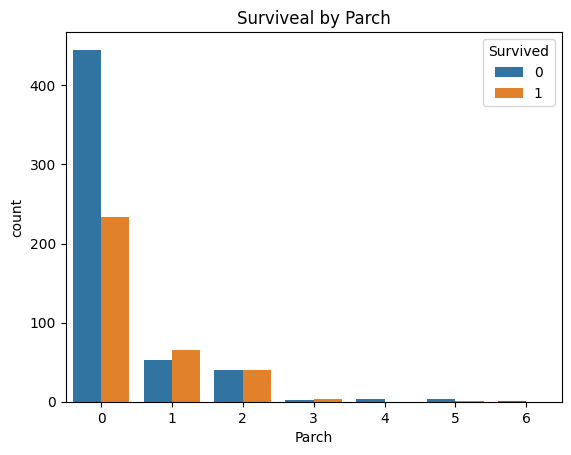

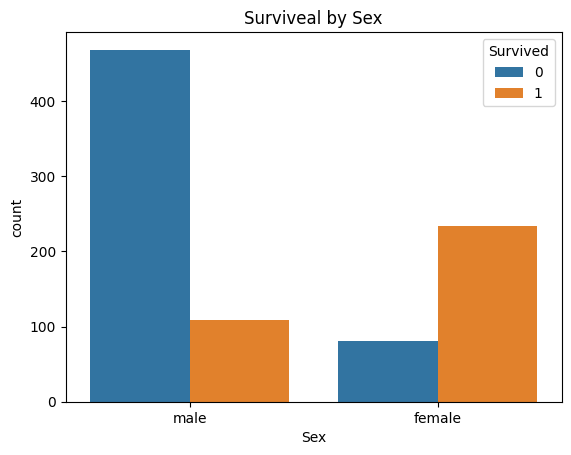

In [13]:
for  feature in [ 'SibSp', 'Parch', 'Sex']:
    plt.title(f'Surviveal by {feature}')
    sns.countplot(data=df_train, x=feature, hue='Survived')
    #plt.yscale('log')
    plt.show()


### Вывод по связи признаков с выживаемостью

- `SibSp`: среди пассажиров без супругов/братьев/сестер (`SibSp = 0`) погибших заметно больше, чем выживших. При `SibSp = 1` соотношение лучше: выживших немного больше, чем погибших. Большие значения `SibSp` встречаются редко, поэтому по ним сложно делать устойчивые выводы.
- `Parch`: у пассажиров без родителей/детей на борту (`Parch = 0`) погибших больше, чем выживших. Для `Parch = 1` и `Parch = 2` соотношение выглядит более сбалансированным 
- `Sex`: самый сильный  сигнал среди этих признаков. Среди мужчин погибших значительно больше, чем выживших, а среди женщин наоборот — выживших намного больше. Признак `Sex` обязательно нужно оставить в модели.

<Axes: >

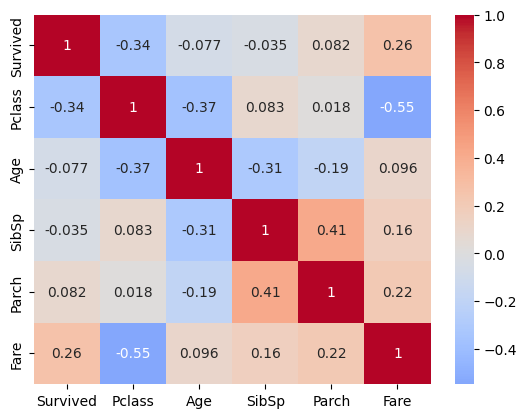

In [14]:
corr_matrix = df_train.corr(numeric_only=True)
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm", center=0)

### Вывод

Корреляционная матрица показывает, что среди числовых признаков с `Survived` заметнее всего связаны `Pclass` (`-0.34`) и `Fare` (`0.26`). Более высокий класс билета и высокая стоимость билета ассоциируются с большей вероятностью выживания. Также видна связь `Pclass` и `Fare` (`-0.55`), что логично: пассажиры 1 класса обычно платили больше. `SibSp` и `Parch` умеренно коррелируют (`0.41`), так как оба признака описывают наличие родственников на борту.

# Cabin availability
Проверяем, связан ли факт наличия каюты с таргетом.


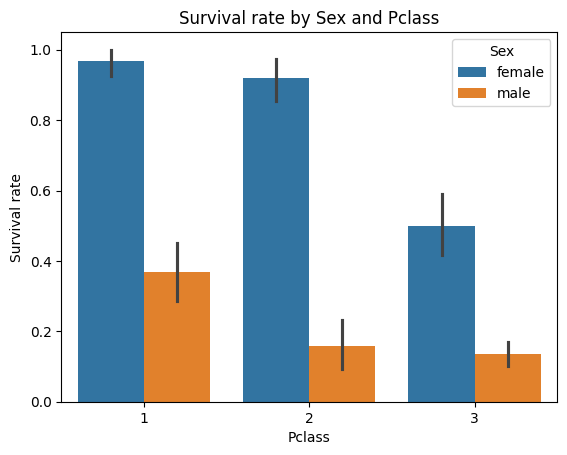

In [23]:
sns.barplot(data=df_train, x="Pclass", y="Survived", hue="Sex")
plt.title("Survival rate by Sex and Pclass")
plt.ylabel("Survival rate")
plt.show()

### Вывод по Cabin

В исходном признаке `Cabin` очень много пропусков, поэтому использовать его напрямую сложно. Однако сам факт наличия записи о каюте связан с выживаемостью: среди пассажиров с указанной каютой доля выживших заметно выше, чем среди пассажиров без указанной каюты.

Поэтому в основном pipeline вместо исходного признака `Cabin` создается бинарный признак `HasCabin`, где `1` означает, что каюта указана, а `0` — что значение пропущено. Исходная колонка `Cabin` затем удаляется.

## Общий вывод

В ходе EDA были выявлены несколько признаков, потенциально важных для предсказания выживаемости пассажиров Titanic.

Наиболее сильный визуальный сигнал дает признак `Sex`: женщины выживали заметно чаще мужчин. Также важным выглядит `Pclass`: пассажиры 1 класса имели более высокую выживаемость, чем пассажиры 2 и 3 классов. Это подтверждается как графиками по группам, так и корреляцией `Pclass` с таргетом.

Признак `Fare` имеет выраженный правый хвост и связан с `Pclass`: пассажиры более высокого класса обычно платили больше. Из-за перекошенного распределения и выбросов для `Fare` в основном pipeline используется логарифмирование `log1p`.

В данных есть пропуски в `Age`, `Cabin` и `Embarked`. Для `Age` требуется численное заполнение, так как доля пропусков заметная. Для `Embarked` достаточно заполнения модой, так как пропусков всего несколько. `Cabin` содержит слишком много пропусков для прямого использования, однако сам факт наличия указанной каюты связан с выживаемостью, поэтому на его основе создается бинарный признак `HasCabin`.

Семейные признаки `SibSp` и `Parch` имеют правосторонний перекос: большинство пассажиров путешествовали без родственников или с небольшим числом родственников. Большие значения встречаются редко, но не являются ошибками — скорее это большие семьи. Эти признаки стоит оставить в модели, а также можно рассмотреть создание дополнительных признаков `FamilySize` и `IsAlone`.

Итоговые решения для основного pipeline: обработать пропуски, создать `HasCabin`, извлечь титулы из `Name`, удалить слишком текстовые или плохо структурированные признаки (`Name`, `Ticket`, `Cabin`), применить `log1p` к `Fare`, закодировать категориальные признаки и сравнить несколько групп моделей на кросс-валидации.